In [ ]:
! pip install chembl_webresource_client

In [ ]:
! pip install rdkit

In [ ]:
from rdkit.Chem import PandasTools
from rdkit import Chem

# библиотека для работы с таблицами
import pandas as pd
# ChEMBL API
from chembl_webresource_client.new_client import new_client
# библиотеки для вычислений
import numpy as np
import math

In [ ]:
target = new_client.target
target_query = target.search('YTHDF3')
protein = pd.DataFrame.from_dict(target_query)
protein.head()

,cross_references,organism,pref_name,score,species_group_flag,target_chembl_id,target_components,target_type,tax_id
0,[],Homo sapiens,YTH domain-containing family protein 3,20.0,False,CHEMBL5169172,"[{'accession': 'Q7Z739', 'component_descriptio...",SINGLE PROTEIN,9606


In [ ]:
selected_target = 'CHEMBL5169172'
activity = new_client.activity
res = activity.filter(target_chembl_id=selected_target).filter(type='IC50')
df = pd.DataFrame.from_dict(res)
df.head()

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,NA,24861467,"[{'comments': None, 'relation': '=', 'result_f...",CHEMBL5149949,Binding affinity to GST-tagged YTHDF3 m6A-read...,B,None,None,BAO_0000190,...,Homo sapiens,YTH domain-containing family protein 3,9606,None,None,IC50,None,None,None,None
1,"{'action_type': 'BINDING AGENT', 'description'...",None,24861468,"[{'comments': None, 'relation': '=', 'result_f...",CHEMBL5149949,Binding affinity to GST-tagged YTHDF3 m6A-read...,B,None,None,BAO_0000190,...,Homo sapiens,YTH domain-containing family protein 3,9606,None,None,IC50,uM,UO_0000065,None,218.0


In [ ]:
df_IC50 = df[['standard_type', 'standard_units', 'standard_value']].copy()
df_IC50

,standard_type,standard_units,standard_value
0,IC50,None,None
1,IC50,nM,218000.0


In [ ]:
# Поиск нулевых значений
df = df[df.standard_value.notna()]
df.shape
print(f"Units in selected data: {df['standard_units'].unique()}")

# Новый чтолбец bioactivity_class
bioactivity_class = []
for i in df.standard_value:
  if float(i) >= 10000:
    bioactivity_class.append("inactive")
  elif float(i) <= 1000:
    bioactivity_class.append("active")
  else:
    bioactivity_class.append("intermediate")
df['bioactivity_class'] = bioactivity_class


Units in selected data: ['nM']


<ipython-input-40-284407e086e0>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['bioactivity_class'] = bioactivity_class


In [ ]:
df = df[['molecule_chembl_id', 'canonical_smiles', 'bioactivity_class', 'standard_value']]
df.head()

,molecule_chembl_id,canonical_smiles,bioactivity_class,standard_value
1,CHEMBL5192478,O=c1cc(C2CC2)[nH]c(=O)[nH]1,inactive,218000.0


In [ ]:
df_IC50 = df[['molecule_chembl_id', 'canonical_smiles', 'bioactivity_class', 'standard_value']]

df_IC50.rename(
    columns={"standard_value": "IC50",}, inplace=True
)
df_IC50.head(106)

,molecule_chembl_id,canonical_smiles,bioactivity_class,IC50
1,CHEMBL5192478,O=c1cc(C2CC2)[nH]c(=O)[nH]1,inactive,218000.0


<Axes: >

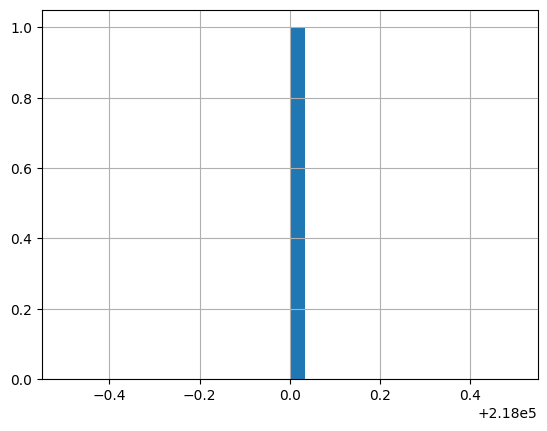

In [ ]:
df_IC50['IC50'] = pd.to_numeric(df_IC50['IC50'])
df_IC50.IC50.hist(bins=30)

In [ ]:
# Пересчет из IC50 в pIC50
def convert_ic50_to_pic50(IC50):
    pIC50 = 9 - math.log10(IC50)
    return pIC50

df_IC50["pIC50"] = df_IC50.apply(lambda x: convert_ic50_to_pic50(x.IC50), axis=1)
df_IC50

,molecule_chembl_id,canonical_smiles,bioactivity_class,IC50,pIC50
1,CHEMBL5192478,O=c1cc(C2CC2)[nH]c(=O)[nH]1,inactive,218000.0,3.661544


<Axes: >

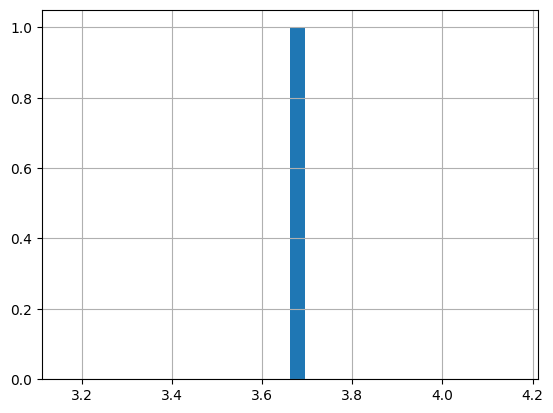

In [ ]:
df_IC50.pIC50.hist(bins=30)

In [ ]:
# Сортировка по pIC50
df_output = df_IC50.sort_values(by="pIC50", ascending=False)
df_output.head(106)

,molecule_chembl_id,canonical_smiles,bioactivity_class,IC50,pIC50
1,CHEMBL5192478,O=c1cc(C2CC2)[nH]c(=O)[nH]1,inactive,218000.0,3.661544


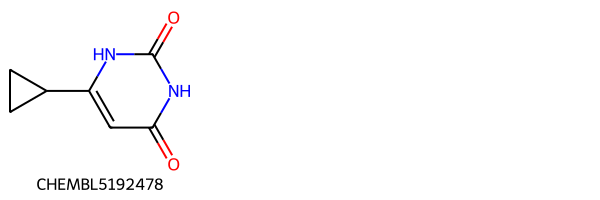

In [ ]:
PandasTools.AddMoleculeColumnToFrame(df_output, smilesCol='canonical_smiles')

Chem.Draw.MolsToGridImage(
    list(df_output.head(3).ROMol),
    legends=list(df_output.head(3).molecule_chembl_id),
)

In [ ]:
# Сохранение данных
df_output.to_csv('data.csv')
df_output.set_index('bioactivity_class')
index = df_output[df_output['bioactivity_class'] == 'inactive'].index
df_output.drop(index, inplace=True)
index = df_output[df_output['bioactivity_class'] == 'intermediate'].index
df_output.drop(index, inplace=True)
df_output

,molecule_chembl_id,canonical_smiles,bioactivity_class,IC50,pIC50,ROMol
